# Lab: Model Inversion (Extracting the "Ghost" in the Machine)


We will use the MNIST model and then "interrogate" it by saying: *"I don't know what a '5' looks like. You tell me what the perfect '5' looks like by shifting these random pixels around."*

### Learning Objective

To demonstrate that machine learning models "remember" the features of their training data, and that these features can be reconstructed by an attacker with access to the model's confidence scores.

---

## 1. The Setup

We will use the same MNIST CNN model from the FGSM lab. Ensure that your `model` object is in `eval()` mode.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# Set device (CPU is perfectly fine for this!)
device = torch.device("cpu")

# Load MNIST test set
train_loader = torch.utils.data.DataLoader(
    datasets.MNIST('../data', train=True, download=True,
                   transform=transforms.Compose([transforms.ToTensor(),])),
    batch_size=1, shuffle=True)

# Load MNIST test set
test_loader = torch.utils.data.DataLoader(
    datasets.MNIST('../data', train=False, download=True,
                   transform=transforms.Compose([transforms.ToTensor(),])),
    batch_size=1, shuffle=True)

---

## 2. The Target Model

We need a model to attack. For a quick demo, we'll define a simple NN and train it for **one epoch**. This may take 5 - 6 minutes.

In [ ]:
class SimpleMLP(nn.Module):
    def __init__(self):
        super(SimpleMLP, self).__init__()
        # MNIST images are 28x28 = 784 pixels
        self.fc1 = nn.Linear(784, 400)
        self.fc2 = nn.Linear(400, 200)
        self.fc3 = nn.Linear(200, 10) # 10 output classes (0-9)

    def forward(self, x):
        # Flatten the image from (Batch, 1, 28, 28) to (Batch, 784)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return F.log_softmax(x, dim=1)

# Initialize
#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")
model = SimpleMLP().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Training simpler model...")
model.train()
# Assuming train_loader is defined
for batch_idx, (data, target) in enumerate(train_loader):
    data, target = data.to(device), target.to(device)
    optimizer.zero_grad()
    output = model(data)
    loss = F.nll_loss(output, target)
    loss.backward()
    optimizer.step()
    if batch_idx % 5000 == 0:
        print(f"Loss: {loss.item():.4f}")

model.eval()
print("Simple MLP ready!")

Training simpler model...
Loss: 2.4262
Loss: 0.0044
Loss: 0.0000
Loss: 0.0000
Loss: 0.0001
Loss: 0.0000
Loss: 0.0066
Loss: 0.0512
Loss: 0.0000
Loss: 0.0000
Loss: 0.0000
Loss: 0.0000
Simple MLP ready!


---

## 2. The Attack: Gradient Ascent on Pixels

In normal training, we keep the data fixed and update the weights. In Model Inversion, we **freeze the weights** and **update the pixels**.

We want to find an image $x$ that maximizes the probability of a `target_class`.

In [ ]:
def invert_class(model, target_class, iterations=50, lr=0.1):
    # 1. Start with pure random noise (representing a blank slate)
    input_noise = torch.randn(1, 1, 28, 28, device=device, requires_grad=True)

    # We use a simple optimizer to handle the pixel updates
    optimizer = torch.optim.Adam([input_noise], lr=lr)

    history = []

    for i in range(iterations):
        optimizer.zero_grad()

        # 2. Ask the model what it thinks of this noise
        output = model(input_noise)

        # 3. Calculate "Loss"
        # We want to MINIMIZE the distance to the target class
        # (Essentially Maximizing the confidence for that class)
        loss = F.nll_loss(output, torch.tensor([target_class]))

        loss.backward()
        optimizer.step()

        # Keep pixels in valid [0, 1] range
        input_noise.data.clamp_(0, 1)

        # Save progress every 5 steps for the "Aha!" moment
        if i % 5 == 0 or i == iterations - 1:
            history.append(input_noise.detach().cpu().clone().squeeze())

    return history


In [ ]:

# Choose a digit to reconstruct
target = 6
print(f"Reconstructing the model's memory of digit: {target}...")
reconstructed_images = invert_class(model, target)

Reconstructing the model's memory of digit: 6...


---

## 3. Visualization: Watching the "Ghost" Appear

We will plot the evolution of the image from random static to a recognizable digit.

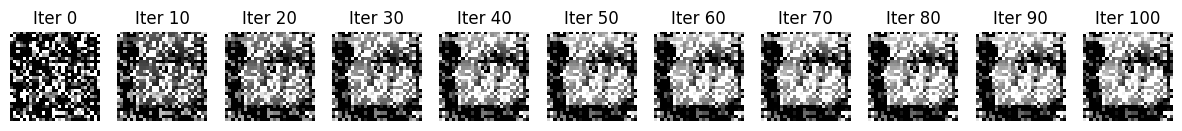

In [ ]:
plt.figure(figsize=(15, 5))
for i, img in enumerate(reconstructed_images):
    plt.subplot(1, len(reconstructed_images), i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(f"Iter {i*10}")
    plt.axis('off')
plt.show()

---

## 4. Verification

Now, we ask the model what it thinks of the image it just "created."

In [ ]:
final_img = reconstructed_images[-1].unsqueeze(0).unsqueeze(0)
output = model(final_img)
confidence = torch.exp(output.max()) * 100
pred = output.argmax().item()

print(f"Final Prediction: {pred}")
print(f"Model Confidence: {confidence:.2f}%")

Final Prediction: 6
Model Confidence: 100.00%


---

## Lab Discussion Questions

### 1. The Visual Quality

**Question:** The reconstructed digit looks "ghostly" or like a blurry average. Why doesn't it look like a crisp, perfect handwritten digit?

* **Answer:** The model didn't memorize one specific "5" from the dataset; it learned the *features* that are common to all 5s. You are seeing the generic 5 according to this specific model's weights.

### 2. Privacy Implications

**Question:** If this were a facial recognition model for a high-security building, what could an attacker do with this technique?

* **Answer:** An attacker could reconstruct the faces of the people allowed in the building (the training set), even if they never had access to the original photos. This is a massive **Privacy Breach**.

### 3. The Comparison

Use the table below to summarize the three labs you have completed:

| Attack Type | Phase | The "Weapon" | The Result |
| --- | --- | --- | --- |
| **Data Poisoning** | Training | Malicious Data | A "Backdoor" trigger |
| **Adversarial Input** | Inference | Calculated Noise | Misclassification |
| **Model Inversion** | Post-Training | Confidence Scores | Reconstructed Training Data |

---